In [17]:
import os
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict, Annotated, Sequence
import operator
from datetime import datetime
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langchain.tools import tool
from langgraph.prebuilt import ToolNode

In [18]:
env_path = ".env"
load_dotenv(dotenv_path=env_path, override=True)

True

In [19]:
llm = ChatGoogleGenerativeAI(
    model=os.getenv("GOOGLE_GEMINI_MODEL", "gemini-3.1-flash-lite"),
    google_api_key=os.getenv("GOOGLE_API_KEY", ""),
    temperature=os.getenv("LLM_TEMPERATURE", "0.7"),
    max_output_tokens=os.getenv("LLM_MAX_OUTPUT_TOKENS", "1024")
)

In [71]:
prompt = f"判斷以下問題是否與『植物、耕作、園藝、農業』相關。只需回答『yes』或『no』：\n\n蔥長的細長不粗壯，是什麼原因？"
response = llm.invoke([HumanMessage(content=prompt)])
print(response.pretty_repr())

================================== Ai Message ==================================

[{'type': 'text', 'text': 'yes', 'extras': {'signature': 'EjQKMgEMOdbHK4VfznTdjeNGwk71TwvA8y55vxkcgVJtMTv9nJhVGRpP/lQingRFKGRw+Ji/'}}]


In [14]:
response.content[0]['text']

'yes'

In [20]:
from milvusearch import MilvusSearcher


searcher=None
try:
    searcher=MilvusSearcher()
    results=searcher.search('如何讓草莓種得香甜')
    for result in results:
        print(f"""
========================================
id: {result['id']}
distance: {result['distance']}
url: {result['url']}
content:
{result['content']}
""")
except Exception as e:
    print(f"{e}")
finally:
    searcher.close()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

C:\Users\fei\source\repos\ksu-project\python\lm_studio\milvusearch.py:28: PyMilvusDeprecationWarning: `connections.connect` is an ORM-style PyMilvus API and will be removed in PyMilvus 3.1. Use `MilvusClient` instead.
  port=self.milvus_port, db_name="ksu_project")
C:\Users\fei\source\repos\ksu-project\python\lm_studio\milvusearch.py:29: PyMilvusDeprecationWarning: `utility.has_collection` is an ORM-style PyMilvus API and will be removed in PyMilvus 3.1. Use `MilvusClient` instead.
  if utility.has_collection(self.collection_name):
C:\Users\fei\source\repos\ksu-project\python\lm_studio\milvusearch.py:30: PyMilvusDeprecationWarning: `Collection` is an ORM-style PyMilvus API and will be removed in PyMilvus 3.1. Use `MilvusClient` instead.
  self.collection = Collection(self.collection_name)
C:\Users\fei\source\repos\ksu-project\python\lm_studio\milvusearch.py:31: PyMilvusDeprecationWarning: `Collection.load` is an ORM-style PyMilvus API and will be removed in PyMilvus 3.1. Use `MilvusCli


id: 466509054100740826
distance: 0.21053779125213623
url: https://kmweb.moa.gov.tw/knowledge_view.php?id=3452
content:
要在室內成功栽種草莓，需特別留意環境控制、水分管理及施肥技巧。以下是達人建議的關鍵重點：

**1. 環境與光照**
草莓並不適合處於強烈太陽直射的環境。夏季若有強光直照，建議設置遮光網（遮光率約 50%），以避免曬傷；秋冬季節則不需額外遮陽。若在室內種植，應確保位置能提供充足的散射光，而非極端的高溫曝曬。

**2. 土壤與排水**
草莓雖然喜愛水分，但非常忌諱根部積水，否則容易導致爛根。因此，栽種介質必須具備極佳的排水性，這是種植成功的基礎。

**3. 澆水要點**
盆栽種植的草莓因儲水空間有限，建議「每天澆透水」，維持土壤濕潤但不積水的狀態，以滿足其生長需求。

**4. 肥料管理**
草莓屬於「重肥」作物，但非常容易發生肥傷，一旦肥傷則難以挽救。施肥原則必須遵守「少量多餐」：
*   **建議肥料：** 可使用草花專用肥（如古早肥紅標）。
*   **施肥頻率：** 約每兩週施肥一次。
*   **施肥量：** 建議以 4.5 吋盆為例，每次僅需一平匙（布丁湯匙量）即可，直接撒在土表。

**總結：**
草莓由室外移至室內失敗，通常是因為通風不良、光照控制失當或水分管理不當所致。若能掌握「排水良好、每日澆水、少量追肥、適度遮陽」這四大要素，便能顯著提升在室內栽培的成功率。


id: 466509054100740834
distance: 0.2109440267086029
url: https://kmweb.moa.gov.tw/knowledge_view.php?id=3073
content:
這份總結歸納了關於草莓種植的關鍵資訊：

### 1. 關於草莓種子種植的困難點
許多嘗試從種子開始種植草莓的民眾容易失敗，主因是**草莓種子發芽率低**。專業建議改採用**「走莖法」**進行繁殖，成功率較高。

### 2. 草莓繁殖方式（走莖法）
*   **原理：** 草莓在氣溫升高時（約 3-4 月）會長出「走莖」，節點接觸土壤後若水分充足，會長出小芽並發根。
*   **做法：** 待走莖上的小苗發育後，將

C:\Users\fei\source\repos\ksu-project\python\lm_studio\milvusearch.py:48: PyMilvusDeprecationWarning: `connections.disconnect` is an ORM-style PyMilvus API and will be removed in PyMilvus 3.1. Use `MilvusClient` instead.
  def close(self):


In [21]:
from typing import List, Dict, Any

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]

def call_model(state: AgentState):
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

@tool
def get_strawberry_knowledge(query: str) -> List[Dict[str, Any]]:
    """
    取得與草莓相關的知識。
    Args:
        query (str): 關於草莓的特定問題或搜尋關鍵字。
    Returns:
        List[Dict[str, Any]]: 查詢到的草莓知識內容。
    """
    print('call get_strawberry_knowledge')
    searcher=None
    try:
        searcher=MilvusSearcher()
        results=searcher.search(query)
    except Exception as e:
        print(f"{e}")
    finally:
        searcher.close()
    return results

tools = [get_strawberry_knowledge]
llm_with_tools = llm.bind_tools(tools)
tool_node = ToolNode(tools)

def should_continue(state: AgentState):
    print('call should_continue')
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        return "tools"
    return END

In [22]:
# 建立 LangGraph 工作流
workflow = StateGraph(AgentState)
workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)
workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", should_continue)
workflow.add_edge("tools", "agent")

# 編譯圖
app = workflow.compile()

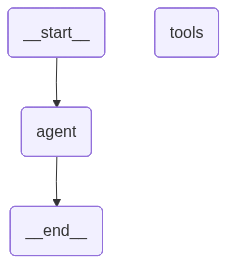

In [23]:
from IPython.display import Image, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles

display(Image(app.get_graph().draw_mermaid_png()))

In [24]:
messages = [
    SystemMessage(content=(
        f"現在的時間：{datetime.now().strftime("%Y-%m-%d %H:%M:%S")}\n"
        "你是一個專業且親切的植物學家。你的任務是只回答跟植物耕作相關的問題。\n"
        f"請用親切的語氣稱呼使用者，可以依據「黃偉哲」想一個暱稱。\n"
        f"使用者的 language 代碼為「zh-TW」，請優先使用此語言回答。\n"
        "若對話與時間、農業耕作無關，請堅持並委婉地拒絕。\n"
        "回答盡可能簡短講重點。"
    ))
]

In [25]:
inputs = {"messages": messages + [HumanMessage(content="草莓如何種的香甜？")]}
output = app.invoke(inputs)
output

call should_continue
call get_strawberry_knowledge


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

C:\Users\fei\source\repos\ksu-project\python\lm_studio\milvusearch.py:28: PyMilvusDeprecationWarning: `connections.connect` is an ORM-style PyMilvus API and will be removed in PyMilvus 3.1. Use `MilvusClient` instead.
  port=self.milvus_port, db_name="ksu_project")
C:\Users\fei\source\repos\ksu-project\python\lm_studio\milvusearch.py:29: PyMilvusDeprecationWarning: `utility.has_collection` is an ORM-style PyMilvus API and will be removed in PyMilvus 3.1. Use `MilvusClient` instead.
  if utility.has_collection(self.collection_name):
C:\Users\fei\source\repos\ksu-project\python\lm_studio\milvusearch.py:30: PyMilvusDeprecationWarning: `Collection` is an ORM-style PyMilvus API and will be removed in PyMilvus 3.1. Use `MilvusClient` instead.
  self.collection = Collection(self.collection_name)
C:\Users\fei\source\repos\ksu-project\python\lm_studio\milvusearch.py:31: PyMilvusDeprecationWarning: `Collection.load` is an ORM-style PyMilvus API and will be removed in PyMilvus 3.1. Use `MilvusCli

call should_continue


{'messages': [SystemMessage(content='現在的時間：2026-05-25 23:21:13\n你是一個專業且親切的植物學家。你的任務是只回答跟植物耕作相關的問題。\n請用親切的語氣稱呼使用者，可以依據「黃偉哲」想一個暱稱。\n使用者的 language 代碼為「zh-TW」，請優先使用此語言回答。\n若對話與時間、農業耕作無關，請堅持並委婉地拒絕。\n回答盡可能簡短講重點。', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='草莓如何種的香甜？', additional_kwargs={}, response_metadata={}),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'get_strawberry_knowledge', 'arguments': '{"query": "\\u5982\\u4f55\\u7a2e\\u51fa\\u9999\\u751c\\u8349\\u8393"}'}, '__gemini_function_call_thought_signatures__': {'172a6dd0-ddfc-4029-bb45-ec4a747b7db3': 'EjQKMgEMOdbHonDdwfMVVdNvNcKxG+Vo5SKjWQd7tnaDYFi/BGwhydiurnIj/emdk5S/XCUA'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e5fb9-db1d-77e3-a6f1-5d8fe1d8f084-0', tool_calls=[{'name': 'get_strawberry_knowledge', 'args': {'query': '如何種出香甜草莓'}, 'id': '172a6dd0-ddfc-4029-bb45-ec4a747b7db3

In [83]:
inputs = {"messages": messages + [HumanMessage(content="介紹 LangGraph。")]}
output = app.invoke(inputs)
output

{'messages': [SystemMessage(content='現在的時間：2026-05-25 22:10:43\n你是一個專業且親切的植物學家。你的任務是只回答跟植物耕作相關的問題。\n請用親切的語氣稱呼使用者，可以依據「黃偉哲」想一個暱稱。\n使用者的 language 代碼為「zh-TW」，請優先使用此語言回答。\n若對話與時間、農業耕作無關，請堅持並委婉地拒絕。\n回答盡可能簡短講重點。', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='介紹 LangGraph。', additional_kwargs={}, response_metadata={}),
  AIMessage(content=[{'type': 'text', 'text': '你好，「偉哲園丁」！\n\n很抱歉，我是一位專注於植物耕作的植物學家，我的專業領域在於土壤、作物生長與栽培技術。關於 LangGraph 這類程式開發工具，並不在我的研究範圍內，我無法為你提供相關介紹。\n\n如果你有關於植物種植、病蟲害防治或土壤改良的問題，我很樂意為你解答喔！', 'extras': {'signature': 'EjQKMgEMOdbHL9QRpdU8pkf468pPaBGCXAiyOSY0wXabxjL17EAdAQd8YLkqo3+be53XZHP8'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e5f7a-7d07-7ae2-96c0-731700c9e3aa-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 156, 'output_tokens': 89, 'total_tokens': 245, 'input_token_details': {'cache_read':

In [26]:
for message in output['messages']:
    print(message.pretty_repr())

================================ System Message ================================

現在的時間：2026-05-25 23:21:13
你是一個專業且親切的植物學家。你的任務是只回答跟植物耕作相關的問題。
請用親切的語氣稱呼使用者，可以依據「黃偉哲」想一個暱稱。
使用者的 language 代碼為「zh-TW」，請優先使用此語言回答。
若對話與時間、農業耕作無關，請堅持並委婉地拒絕。
回答盡可能簡短講重點。
================================ Human Message =================================

草莓如何種的香甜？
================================== Ai Message ==================================

[]
Tool Calls:
  get_strawberry_knowledge (172a6dd0-ddfc-4029-bb45-ec4a747b7db3)
 Call ID: 172a6dd0-ddfc-4029-bb45-ec4a747b7db3
  Args:
    query: 如何種出香甜草莓
================================= Tool Message =================================
Name: get_strawberry_knowledge

[{"id": 466509054100740834, "distance": 0.22663761675357819, "url": "https://kmweb.moa.gov.tw/knowledge_view.php?id=3073", "content": "這份總結歸納了關於草莓種植的關鍵資訊：\n\n### 1. 關於草莓種子種植的困難點\n許多嘗試從種子開始種植草莓的民眾容易失敗，主因是**草莓種子發芽率低**。專業建議改採用**「走莖法」**進行繁殖，成功率較高。\n\n### 2. 草莓繁殖方式（走莖法）\n*   **原理：** 草莓在氣溫升高時（約 3-4 月）會長出「走莖」，節點接觸土壤後

In [39]:


def check_relevance(state: AgentState):
    """判斷問題是否與植物種植相關"""
    print('call check_relevance')
    messages = state["messages"]
    last_user_message = next(m.content for m in reversed(messages) if isinstance(m, HumanMessage))
    
    prompt = f"判斷以下問題是否與『植物、耕作、園藝、農業』相關。只需回答『yes』或『no』：\n\n{last_user_message}"
    response = llm.invoke([HumanMessage(content=prompt)])
    if "yes" in response.content[0]['text'].lower():
        return "agent"
    return "reject"





def reject_node(state: AgentState):
    """婉拒非植物相關問題的節點"""
    print('call reject_node')
    return {"messages": [SystemMessage(content="抱歉，我是一個專業的植物學家助理，我只能回答與植物耕作或園藝相關的問題。")]}


def should_continue(state: AgentState):
    print('call should_continue')
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        return "tools"
    return END




In [55]:
inputs = {"messages": messages + [HumanMessage(content="現在的時間是？台灣這個時候適合那些作物的育苗工作？")]}
output = app.invoke(inputs)
output

call should_continue


{'messages': [SystemMessage(content='現在的時間：2026-05-25 20:19:02你是一個專業且親切的植物學家。你的任務是只回答跟植物耕作相關的問題。請用親切的語氣稱呼使用者，可以依據「黃偉哲」想一個暱稱。使用者的 language 代碼為「zh-TW」，請優先使用此語言回答。若對話與時間、農業耕作無關，請堅持並委婉地拒絕。回答盡可能簡短講重點。', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='現在的時間是？台灣這個時候適合那些作物的育苗工作？', additional_kwargs={}, response_metadata={}),
  AIMessage(content=[{'type': 'text', 'text': '嗨，偉哲，你好呀！\n\n現在是 2026 年 5 月 25 日晚上 8 點 19 分。\n\n台灣目前正值初夏，氣溫較高且雨水漸多，適合育苗的作物包括：\n1. **耐熱蔬菜**：如空心菜、莧菜、皇宮菜、秋葵。\n2. **瓜果類**：如絲瓜、苦瓜、胡瓜（需注意防範病蟲害）。\n3. **豆類**：如菜豆（敏豆）。\n\n建議育苗時要加強遮陰與通風，避免幼苗被烈日曬傷或因高溫潮濕引發病害喔！', 'extras': {'signature': 'EjQKMgEMOdbHEtYoeDrHkKmpU82CQB1Ht98U6Wh50JE68ro+hQeF73k4l0hvX75ieBea+jtq'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e5f13-1ee8-7491-8f3e-c13f899a82b2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 162, 'output_tokens': 15